# Tabby English — Phase 2

Phase 1에 더해 다음 세 가지가 추가됩니다:

1. **Conditional edges** — 입력 신호(utterance / silence / end_session)에 따라 3갈래 분기
2. **Tool 사용** — 머뭇거림 시 LLM이 사전 도구를 호출해 더 나은 추천어 생성
3. **Checkpointer** — 세션이 자동 저장되어 노트북을 닫아도 이어서 진행 가능

## 입력 시뮬레이션

- 일반 발화: 영어 문장 입력 → AI 대화 상대가 응답
- 머뭇거림: **빈 문자열 `""`** 입력 → 추천어 3개 반환
- 종료: `"end"` 입력 → 피드백 생성 + DB 저장


## 1. 환경 설정


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT: Path = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError(
        f"main.ipynb를 프로젝트 루트(tabby-english/)에 두세요. 현재: {PROJECT_ROOT}"
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("프로젝트 루트:", PROJECT_ROOT)

프로젝트 루트: C:\Users\yun\Documents\code\tabby-english


In [2]:
import json
import uuid
from typing import cast

from dotenv import load_dotenv
from langgraph.graph.state import CompiledStateGraph

from src.graph import build_graph
from src.state import ConversationState, Feedback

load_dotenv()
print("import 완료")

import 완료


## 2. 그래프 빌드 + 시각화


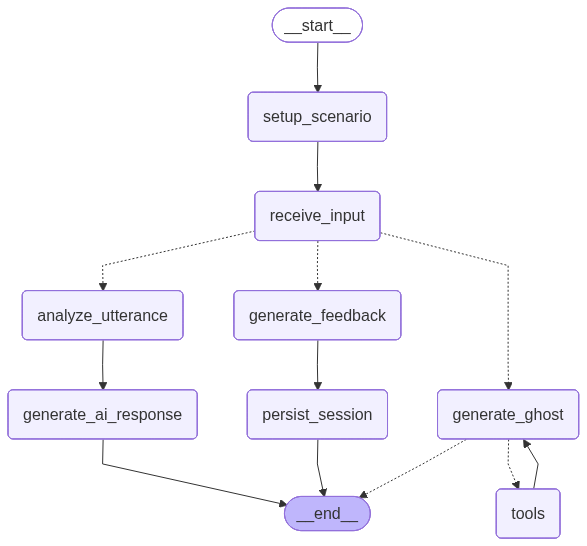

In [3]:
app: CompiledStateGraph = build_graph()

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 3. 세션 초기화

`thread_id`는 Checkpointer가 세션을 식별하는 키입니다.  
**같은 thread_id로 다시 실행하면 이전 대화를 이어갈 수 있습니다.**


In [4]:
# 새 세션을 시작할 때마다 새 thread_id 생성
thread_id: str = f"session_{uuid.uuid4().hex[:8]}"
config = {"configurable": {"thread_id": thread_id}}

scenario: str = "ordering at a cafe"

# 초기 State (Checkpointer가 첫 invoke부터 자동 저장)
init_state: ConversationState = {
    "scenario": scenario,
    "system_prompt": "",
    "raw_input": "",
    "input_signal": "utterance",
    "conversation_history": [],
    "messages": [],
    "last_ai_response": "",
    "ghost_suggestions": [],
    "feedback": {},
}

print(f"thread_id: {thread_id}")
print(f"시나리오:  {scenario}")

thread_id: session_a79b1470
시나리오:  ordering at a cafe


## 4. 대화 (반복 실행)

아래 셀의 `user_input`을 바꿔가며 실행하세요.

- 영어 문장 → AI 응답
- `""` (빈 문자열) → 추천어 3개
- `"end"` → 종료 + 피드백


In [9]:
# 매 턴 이 부분만 바꿔서 실행
user_input: str = "end"

# Checkpointer 덕에 init_state는 첫 호출에서만 사용되고,
# 이후 호출은 thread_id로 이전 상태를 자동 복원한다.
result = cast(
    ConversationState,
    app.invoke(
        {**init_state, "raw_input": user_input},
        config=config,
    ),
)

# signal에 따라 다른 출력
signal = result.get("input_signal")

if signal == "utterance":
    print(f"You:     {user_input}")
    print(f"Partner: {result.get('last_ai_response', '')}")
elif signal == "silence":
    print("💡 추천 표현:")
    for s in result.get("ghost_suggestions", []):
        print(f"   • {s}")
elif signal == "end_session":
    print("세션이 종료되어 피드백이 생성되고 DB에 저장되었습니다.")
    print(json.dumps(result.get("feedback", {}), ensure_ascii=False, indent=2))

세션이 종료되어 피드백이 생성되고 DB에 저장되었습니다.
{
  "summary": "학습자는 카페에서 커피를 주문하는 상황을 잘 표현했습니다. 다양한 음료를 요청하고 결제하는 과정도 매끄럽게 진행되었습니다.",
  "improvements": [
    {
      "original": "Here cash is",
      "suggestion": "Here is the cash.",
      "reason": "문장의 구조가 자연스럽지 않아 의미 전달이 매끄럽지 않습니다. 'Here is the cash.'로 표현하면 더 자연스럽습니다."
    }
  ],
  "good_points": [
    "주문할 음료를 명확하게 나열하여 상대방이 이해하기 쉽게 표현했습니다."
  ]
}


### 전체 대화 기록 확인


In [10]:
# Checkpointer에 저장된 최신 State를 가져온다
snapshot = app.get_state(config)
for entry in snapshot.values.get("conversation_history", []):
    speaker = "You    " if entry["role"] == "user" else "Partner"
    print(f"{speaker}: {entry['text']}")

You    : Hi, I would like to order a coffee
Partner: Sure! What kind of coffee would you like?
You    : One iced americano and one hot latte and do you also have a cold brew?
Partner: Yes, we do have cold brew! Would you like to add that to your order?
You    : Yes, one cold brew more please. Here cash is
Partner: Great! So that's one iced Americano, one hot latte, and one cold brew. Thank you for the cash! Your total is $15. Your drinks will be ready shortly. Would you like anything to eat with that?
You    : I think that's all. thanks
Partner: You're welcome! Enjoy your drinks! If you need anything else, just let me know.


## 5. 저장된 학습 세션 조회

`persist_session` 노드가 `data/sessions.db`에 저장한 세션들을 조회합니다.


In [11]:
import sqlite3

with sqlite3.connect("data/sessions.db") as conn:
    rows = conn.execute(
        "SELECT id, ended_at, scenario, turn_count FROM learning_sessions ORDER BY id DESC LIMIT 5"
    ).fetchall()

if rows:
    print(f"{'ID':<4}{'종료시각':<22}{'시나리오':<25}턴 수")
    print("─" * 60)
    for row in rows:
        print(f"{row[0]:<4}{row[1]:<22}{row[2]:<25}{row[3]}")
else:
    print("아직 종료된 세션이 없습니다.")

ID  종료시각                  시나리오                     턴 수
────────────────────────────────────────────────────────────
3   2026-05-09T15:35:44   ordering at a cafe       4
2   2026-05-09T15:06:48   ordering at a cafe       6
1   2026-05-09T14:58:47   ordering at a cafe       7


## 6. 세션 재개 시연 (선택)

위에서 만든 `thread_id`를 다른 변수로 옮겨두고 새 init_state로 시도해보면,  
Checkpointer가 이전 대화를 그대로 들고 있는 걸 확인할 수 있습니다.


In [12]:
# 같은 thread_id로 State를 조회 — 이전 대화가 그대로 살아있음
snapshot = app.get_state(config)
print(f"저장된 turn 수: {len(snapshot.values.get('conversation_history', []))}")
print(f"마지막 signal: {snapshot.values.get('input_signal')}")
print()
print("이 thread_id로 다시 turn 셀을 실행하면 대화가 이어집니다.")

저장된 turn 수: 8
마지막 signal: end_session

이 thread_id로 다시 turn 셀을 실행하면 대화가 이어집니다.
